Found 364 images belonging to 3 classes.
Found 104 images belonging to 3 classes.
Training model with relu activation function...
87910968/87910968 [==============================] - 0s 0us/step
Epoch 1/30
11/11 [==============================] - ETA: 0s - loss: 9.4137 - accuracy: 0.3614 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


11/11 [==============================] - 230s 18s/step - loss: 9.4137 - accuracy: 0.3614 - val_loss: 8.9055 - val_accuracy: 0.7812 - lr: 1.0000e-05
Epoch 2/30
11/11 [==============================] - 201s 19s/step - loss: 9.0122 - accuracy: 0.6325 - val_loss: 8.9052 - val_accuracy: 0.7604 - lr: 1.0000e-05
Epoch 3/30
11/11 [==============================] - 198s 18s/step - loss: 8.8354 - accuracy: 0.7711 - val_loss: 8.8375 - val_accuracy: 0.7917 - lr: 1.0000e-05
Epoch 4/30
11/11 [==============================] - 197s 18s/step - loss: 8.8162 - accuracy: 0.7681 - val_loss: 8.8137 - val_accuracy: 0.7917 - lr: 1.0000e-05
Epoch 5/30
11/11 [==============================] - 190s 17s/step - loss: 8.7571 - accuracy: 0.7741 - val_loss: 8.7200 - val_accuracy: 0.8021 - lr: 1.0000e-05
Epoch 6/30
11/11 [==============================] - 196s 18s/step - loss: 8.6838 - accuracy: 0.7922 - val_loss: 8.7275 - val_accuracy: 0.7812 - lr: 1.0000e-05
Epoch 7/30
11/11 [==============================] - 196s 

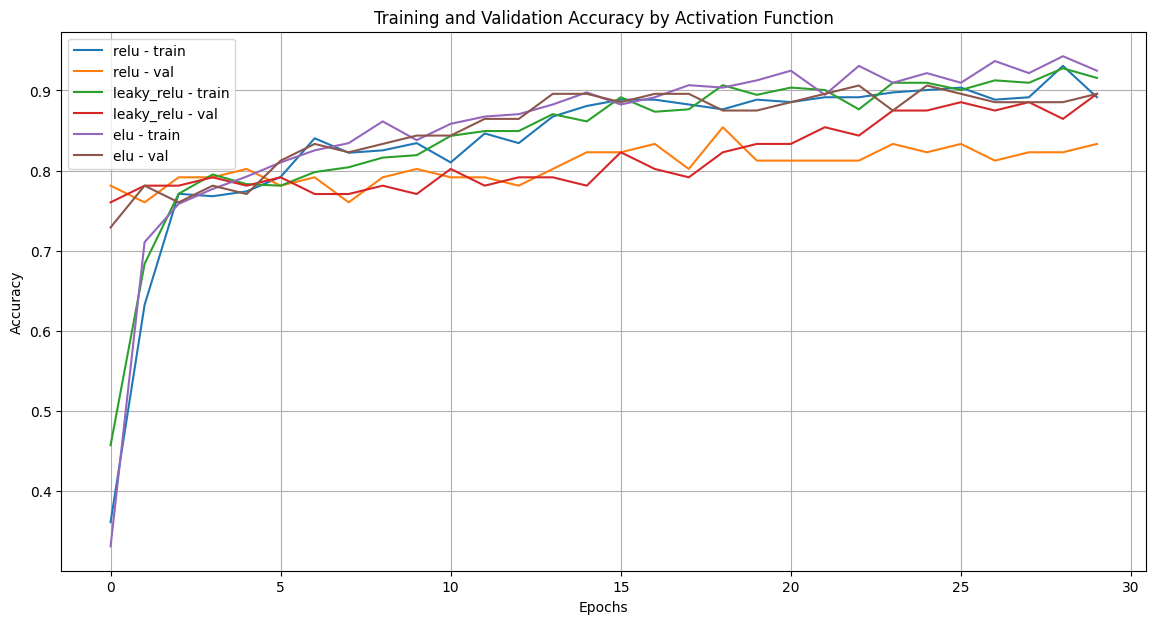

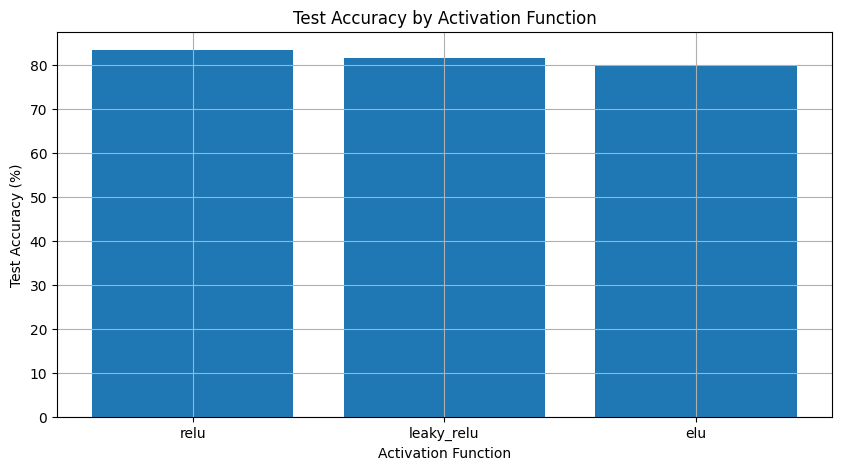

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, LeakyReLU, ELU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Directories for the dataset
train_dir = '/content/drive/MyDrive/Colab Notebooks/organized_data/train'
validation_dir = '/content/drive/MyDrive/Colab Notebooks/organized_data/validation'
test_dir = '/content/drive/MyDrive/Colab Notebooks/organized_data/test'

# Create ImageDataGenerators with enhanced augmentation for the training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=30.0
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

def create_model(activation_function):
    # Load the pre-trained InceptionV3 model
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Add custom top layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, kernel_regularizer=l2(0.01))(x)
    if activation_function == 'leaky_relu':
        x = LeakyReLU(alpha=0.1)(x)
    elif activation_function == 'elu':
        x = ELU(alpha=1.0)(x)
    else:
        x = tf.keras.layers.Activation(activation_function)(x)
    x = Dropout(0.5)(x)
    predictions = Dense(3, activation='softmax')(x)  # Assuming 3 classes: MS, NMO, and healthy

    # Create the full model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Unfreeze the top 50 layers of the base model for fine-tuning
    for layer in base_model.layers[-50:]:
        layer.trainable = True

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Callbacks for learning rate reduction, early stopping, and model checkpointing
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

activation_functions = ['relu', 'leaky_relu', 'elu']
histories = {}

for activation in activation_functions:
    print(f'Training model with {activation} activation function...')
    model = create_model(activation)
    history = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        epochs=30,
        callbacks=[reduce_lr, early_stopping, model_checkpoint]
    )
    histories[activation] = history

# Evaluate each model and store the test accuracy
test_generator = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_accuracies = {}

for activation in activation_functions:
    model = create_model(activation)
    model.load_weights('best_model.h5')
    if test_generator.samples == 0:
        print(f"Error: No test samples found for {activation} activation function. Check the 'test_dir' path and contents.")
    else:
        loss, accuracy = model.evaluate(test_generator)
        test_accuracies[activation] = accuracy
        print(f'Test Accuracy with {activation} activation: {accuracy * 100:.2f}%')

# Plotting the training and validation accuracy for each activation function
plt.figure(figsize=(14, 7))

for activation in activation_functions:
    history = histories[activation]
    plt.plot(history.history['accuracy'], label=f'{activation} - train')
    plt.plot(history.history['val_accuracy'], label=f'{activation} - val')

plt.title('Training and Validation Accuracy by Activation Function')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the test accuracies for each activation function
plt.figure(figsize=(10, 5))
plt.bar(test_accuracies.keys(), [acc * 100 for acc in test_accuracies.values()])
plt.title('Test Accuracy by Activation Function')
plt.xlabel('Activation Function')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Function to preprocess and predict an image
def predict_image(img_path, model_path='best_model.h5'): # Assuming 'best_model.h5' is your saved model
    # Load the trained model
    model = load_model(model_path) # Removed extra space here

    # Load and preprocess the image
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # Rescale
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make a prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]

    # Need to define class_labels for this to work
    class_labels = ['MS', 'NMO', 'healthy'] # Replace with your actual class labels

    return class_labels[predicted_class], predictions[0]

# Example usage
img_path = '/content/drive/MyDrive/Colab Notebooks/organized_data/test/healthy/Te-noTr_0002.jpg'
predicted_class, predictions = predict_image(img_path)
print(f'Predicted class: {predicted_class}')
print(f'Class probabilities: {predictions}')


1/1 [==============================] - 2s 2s/step
Predicted class: healthy
Class probabilities: [0.06626001 0.07628124 0.8574587 ]
